In [1]:
%matplotlib widget
import os
import sys
import glob
import torch
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# Add SAM2 to path to ensure its modules are importable
SAM2_ROOT = os.path.abspath("SAM2/sam2")
if SAM2_ROOT not in sys.path:
    sys.path.insert(0, SAM2_ROOT)

from sam2.build_sam import build_sam2_video_predictor

# --- Configuration ---
FRAMES_DIR = "frames/under/Bottom_Freestyle_P035"
CHECKPOINT = "SAM2/sam2/checkpoints/sam2.1_hiera_large.pt"
MODEL_CFG = "configs/sam2.1/sam2.1_hiera_l.yaml"
OUTPUT_CSV = "ground_truth_markers_P035.csv"

# Fetch frame sequence
frame_paths = sorted(
    glob.glob(os.path.join(FRAMES_DIR, "*.jpg")) +
    glob.glob(os.path.join(FRAMES_DIR, "*.jpeg")),
    key=lambda p: int(''.join(filter(str.isdigit, os.path.splitext(os.path.basename(p))[0])))
)
assert len(frame_paths) > 0, f"No frames found in {FRAMES_DIR}"

# --- Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

# Initialize SAM2 Video Predictor
print("Loading SAM2 model...")
predictor = build_sam2_video_predictor(MODEL_CFG, CHECKPOINT, device=device.type)
print("Model loaded successfully.")

Using device: cuda
Loading SAM2 model...
Model loaded successfully.


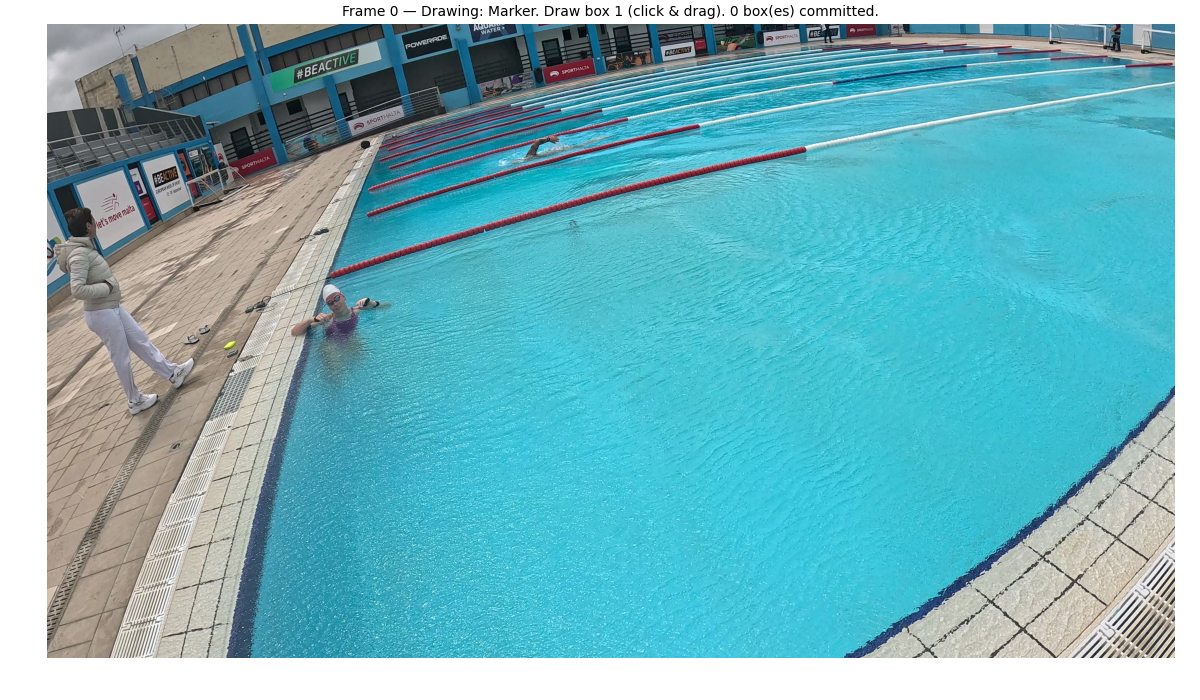

In [2]:
# --- Interactive Marker Prompting ---
import tempfile
import shutil
import ipywidgets as widgets
from IPython.display import display
import matplotlib.patches as mpatches
import json

%matplotlib widget

FILENAME = os.path.basename(FRAMES_DIR) # Derive a filename-like key from the folder name
FORCE_REANNOTATION = False

# Load sorted frame paths
_frame_paths = sorted(
    glob.glob(os.path.join(FRAMES_DIR, "*.jpg")) +
    glob.glob(os.path.join(FRAMES_DIR, "*.jpeg")),
    key=lambda p: int(''.join(filter(str.isdigit, os.path.splitext(os.path.basename(p))[0])))
)
assert _frame_paths, f"No JPEG frames found in {FRAMES_DIR}"

_ANNOTATIONS_FILE = "annotations.json"

def _load_annotations():
    if os.path.exists(_ANNOTATIONS_FILE):
        with open(_ANNOTATIONS_FILE) as f:
            return json.load(f)
    return {}

_annotations = _load_annotations()
_saved = _annotations.get(FILENAME)

# Backward compatibility: old format stored a single "box", new stores "boxes" list
if _saved and "box" in _saved and "boxes" not in _saved:
    _saved["boxes"] = [_saved["box"]]

_BOX_COLORS = {0: 'lime'}  # class 0 = marker
_CLASS_NAMES = {0: 'Marker'}
_state = {"frame_idx": 0, "press": None, "boxes": [], "classes": []}  # classes[i] = 0

if _saved and not FORCE_REANNOTATION:
    _state["frame_idx"] = _saved["frame_idx"]
    _state["boxes"]     = _saved["boxes"]
    _state["classes"]   = _saved.get("classes", [0] * len(_saved["boxes"]))
    print(f"Loaded saved annotation for '{FILENAME}':")
    print(f"  frame_idx = {_saved['frame_idx']}")
    for i, (b, c) in enumerate(zip(_saved["boxes"], _state["classes"])):
        print(f"  box[{i}]    = {[round(v) for v in b]}  class={c} ({_CLASS_NAMES[c]})")
    print(f"\n{len(_saved['boxes'])} box(es) loaded. Run the next cell to confirm, or set FORCE_REANNOTATION = True to redo.")
else:
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.canvas.header_visible = False  # type: ignore
    fig.tight_layout()

    def _load_rgb(idx):
        return cv2.cvtColor(cv2.imread(_frame_paths[idx]), cv2.COLOR_BGR2RGB)  # type: ignore

    _img_disp = ax.imshow(_load_rgb(0))
    _draft_rect = mpatches.Rectangle((0, 0), 0, 0, linewidth=2,
                                      edgecolor='white', facecolor='none', linestyle='--')
    ax.add_patch(_draft_rect)
    ax.set_axis_off()

    _permanent_artists = []  # list of (rect_patch, text_artist) per committed box

    def _update_title():
        n = len(_state["boxes"])
        mode = 'Marker'
        ax.set_title(
            f"Frame {_state['frame_idx']} — Drawing: {mode}. "
            f"Draw box {n + 1} (click & drag). {n} box(es) committed.",
            fontsize=10
        )
        fig.canvas.draw_idle()

    _update_title()

    _slider = widgets.IntSlider(
        value=0, min=0, max=len(_frame_paths) - 1, description='Frame:',
        continuous_update=False,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='80%')
    )
    _undo_btn = widgets.Button(description="Undo last box",
                               button_style='warning',
                               layout=widgets.Layout(width='150px'))

    def _redraw_permanent():
        for rect, txt in _permanent_artists:
            rect.remove()
            txt.remove()
        _permanent_artists.clear()
        for i, (box, cls) in enumerate(zip(_state["boxes"], _state["classes"])):
            color = _BOX_COLORS.get(cls, 'white')
            r = mpatches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(r)
            label = f"{_CLASS_NAMES.get(cls, str(cls))} {i + 1}"
            t = ax.text(box[0] + 4, box[1] + 14, label,
                        color=color, fontsize=9, fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))
            _permanent_artists.append((r, t))
        fig.canvas.draw_idle()

    def _on_frame_change(change):
        _state["frame_idx"] = change["new"]
        _img_disp.set_data(_load_rgb(_state["frame_idx"]))
        _update_title()

    def _on_undo(_):
        if _state["boxes"]:
            _state["boxes"].pop()
            _state["classes"].pop()
            _redraw_permanent()
            _update_title()

    _slider.observe(_on_frame_change, names='value')
    _undo_btn.on_click(_on_undo)

    def _on_press(event):
        if event.inaxes != ax: return
        _state["press"] = (event.xdata, event.ydata)
        _draft_rect.set_xy((event.xdata, event.ydata))
        _draft_rect.set_width(0)
        _draft_rect.set_height(0)

    def _on_motion(event):
        if event.inaxes != ax or _state["press"] is None: return
        x0, y0 = _state["press"]
        x1, y1 = event.xdata, event.ydata
        _draft_rect.set_xy((min(x0, x1), min(y0, y1)))
        _draft_rect.set_width(abs(x1 - x0))
        _draft_rect.set_height(abs(y1 - y0))
        fig.canvas.draw_idle()

    def _on_release(event):
        if event.inaxes != ax or _state["press"] is None: return
        x0, y0 = _state["press"]
        x1, y1 = event.xdata, event.ydata
        _state["press"] = None
        _draft_rect.set_width(0)
        _draft_rect.set_height(0)
        new_box = [min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1)]
        new_cls = 0  # 0 = marker
        _state["boxes"].append(new_box)
        _state["classes"].append(new_cls)
        _redraw_permanent()
        _update_title()
        print(f"{_CLASS_NAMES[new_cls]} box set: {[round(v) for v in new_box]}")

    fig.canvas.mpl_connect('button_press_event', _on_press)
    fig.canvas.mpl_connect('motion_notify_event', _on_motion)
    fig.canvas.mpl_connect('button_release_event', _on_release)

    display(widgets.HBox([_slider, _undo_btn]))
    plt.show()

In [3]:
# --- Tracking Evaluation & Bounding Box Extraction ---
# Uses the annotation box initialized above. Please run this cell ONLY after 
# you interact with the plot above at least once.
from ultralytics import YOLO

# Normalize interactive state for this tracking cell
_state["start_frame_idx"] = int(_state.get("frame_idx", 0))

if "obj_id" not in _state:
    _state["obj_id"] = 1

boxes = _state.get("boxes", [])
assert len(boxes) > 0, "Please draw at least one marker box above before tracking."

def get_mask_bbox(mask):
    """
    Returns (cx_px, cy_px, w_px, h_px) bounding box info for a binary mask,
    or None if the mask is empty.
    """
    if not np.any(mask):
        return None
    mask_uint8 = (mask * 255).astype(np.uint8)
    x, y, w, h = cv2.boundingRect(mask_uint8)
    return x, y, w, h

# Setup YOLO for fallback detection
try:
    yolo_model = YOLO(
        "runs/detect/runs/detect/marker_detector/weights/best.pt")
    print("Loaded fine-tuned YOLO model for fallback.")
except:
    yolo_model = YOLO("yolov8n.pt")
    print("Loaded base YOLO model for fallback (fine-tuned not found).")

start_frame = _state['start_frame_idx']
print(f"Starting SAM2 tracking from Frame {start_frame}")

total_frames = len(frame_paths)
chunk_size = 200

# Results accumulator
tracked_records = []

global_idx = start_frame
tracking_active = True
current_box = np.array(boxes[0], dtype=np.float32)
obj_id = _state["obj_id"]

while global_idx < total_frames:
    chunk_begin = (global_idx // chunk_size) * chunk_size
    chunk_end = min(chunk_begin + chunk_size, total_frames)
    chunk_paths = frame_paths[chunk_begin:chunk_end]
    
    local_start = global_idx - chunk_begin
    print(f"\nProcessing chunk frames {chunk_begin} to {chunk_end-1} | Current frame: {global_idx}")
    
    with tempfile.TemporaryDirectory() as tmp_dir:
        # Load local copies of frames to satisfy SAM2 expectations
        for i, p in enumerate(chunk_paths):
            shutil.copy2(p, os.path.join(tmp_dir, f"{i:05d}.jpg"))

        inference_state = predictor.init_state(video_path=tmp_dir)
        predictor.reset_state(inference_state)

        # If tracking was lost, search forward in the chunk using YOLO
        if not tracking_active:
            found = False
            for l_idx in range(local_start, len(chunk_paths)):
                g_idx = chunk_begin + l_idx
                results = yolo_model(frame_paths[g_idx], verbose=False)
                
                # Check for detections
                if len(results[0].boxes) > 0:
                    pred_boxes = results[0].boxes.xyxy.cpu().numpy()
                    confs = results[0].boxes.conf.cpu().numpy()
                    best_idx = np.argmax(confs)
                    
                    if confs[best_idx] > 0.5: # Confidence threshold
                        current_box = pred_boxes[best_idx].astype(np.float32)
                        obj_id += 1 # Increment object ID for the new track
                        tracking_active = True
                        local_start = l_idx
                        global_idx = g_idx
                        found = True
                        print(f"  [YOLO Fallback] Found new marker at frame {global_idx} (conf: {confs[best_idx]:.2f}). Resuming SAM2...")
                        break
                        
            if not found:
                global_idx = chunk_end # Skip the rest of this chunk as no markers were found
                continue

        # If tracking is active (either inherited or newly found by YOLO)
        if tracking_active:
            _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=local_start,
                obj_id=obj_id,
                box=current_box,
            )

            # Predict frames via SAM2
            with torch.inference_mode():
                for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
                    # SAM2 might yield frames prior to local_start, so we skip them
                    if out_frame_idx < local_start:
                        continue
                        
                    global_frame_idx = chunk_begin + out_frame_idx
                    mask = (out_mask_logits[0] > 0.0).cpu().numpy().squeeze()
                    
                    bbox = get_mask_bbox(mask)
                    if bbox is not None:
                        rx, ry, rw, rh = bbox
                        tracked_records.append({
                            "Frame_ID": global_frame_idx,
                            "Marker_ID": obj_id,
                            "Image_Path": os.path.basename(frame_paths[global_frame_idx]),
                            "X_min": rx,
                            "Y_min": ry,
                            "X_max": rx + rw,
                            "Y_max": ry + rh
                        })
                        # Update current box in case we cross a chunk boundary 
                        current_box = np.array([rx, ry, rx+rw, ry+rh], dtype=np.float32)
                        global_idx = global_frame_idx + 1 # Tracked successfully
                    else:
                        print(f"  [SAM2 Track Lost] at frame {global_frame_idx}. Switching to YOLO scan...")
                        tracking_active = False
                        global_idx = global_frame_idx # Restart loop from this frame to scan
                        break
                        
        # Release GPU tensors
        del inference_state
        torch.cuda.empty_cache()

# Generate DataFrame and Save to CSV
df_gt = pd.DataFrame(tracked_records)
df_gt.to_csv(OUTPUT_CSV, index=False)

print(f"\nTracking Complete. Extracted {len(df_gt)} frames of ground-truth.")
print(f"Results saved to '{OUTPUT_CSV}'. You can now use these bounding boxes for evaluation.")
df_gt.head()

AssertionError: Please draw at least one marker box above before tracking.

Loaded evaluation model: runs/detect/runs/detect/marker_detector/weights/best.pt

Preparing temporary dataset for native YOLO validation...
Running YOLO validation metrics calculation...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.12.0.dev20260302+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 1.3±0.2 ms, read: 163.1±8.2 MB/s, size: 1033.7 KB)
val: Scanning /mnt/c/Users/Daniel/OneDrive/Desktop/Programs/Python/FYP/temp_yolo_eval/labels... 4291 images, 1423 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4291/4291 812.4it/s 5.3s0.1s
val: New cache created: /mnt/c/Users/Daniel/OneDrive/Desktop/Programs/Python/FYP/temp_yolo_eval/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 269/269 8.6it/s 31.2s<0.1ss
                   all       4291       2868      0.403      0.726      0.434      0.274
Speed: 0.6ms p

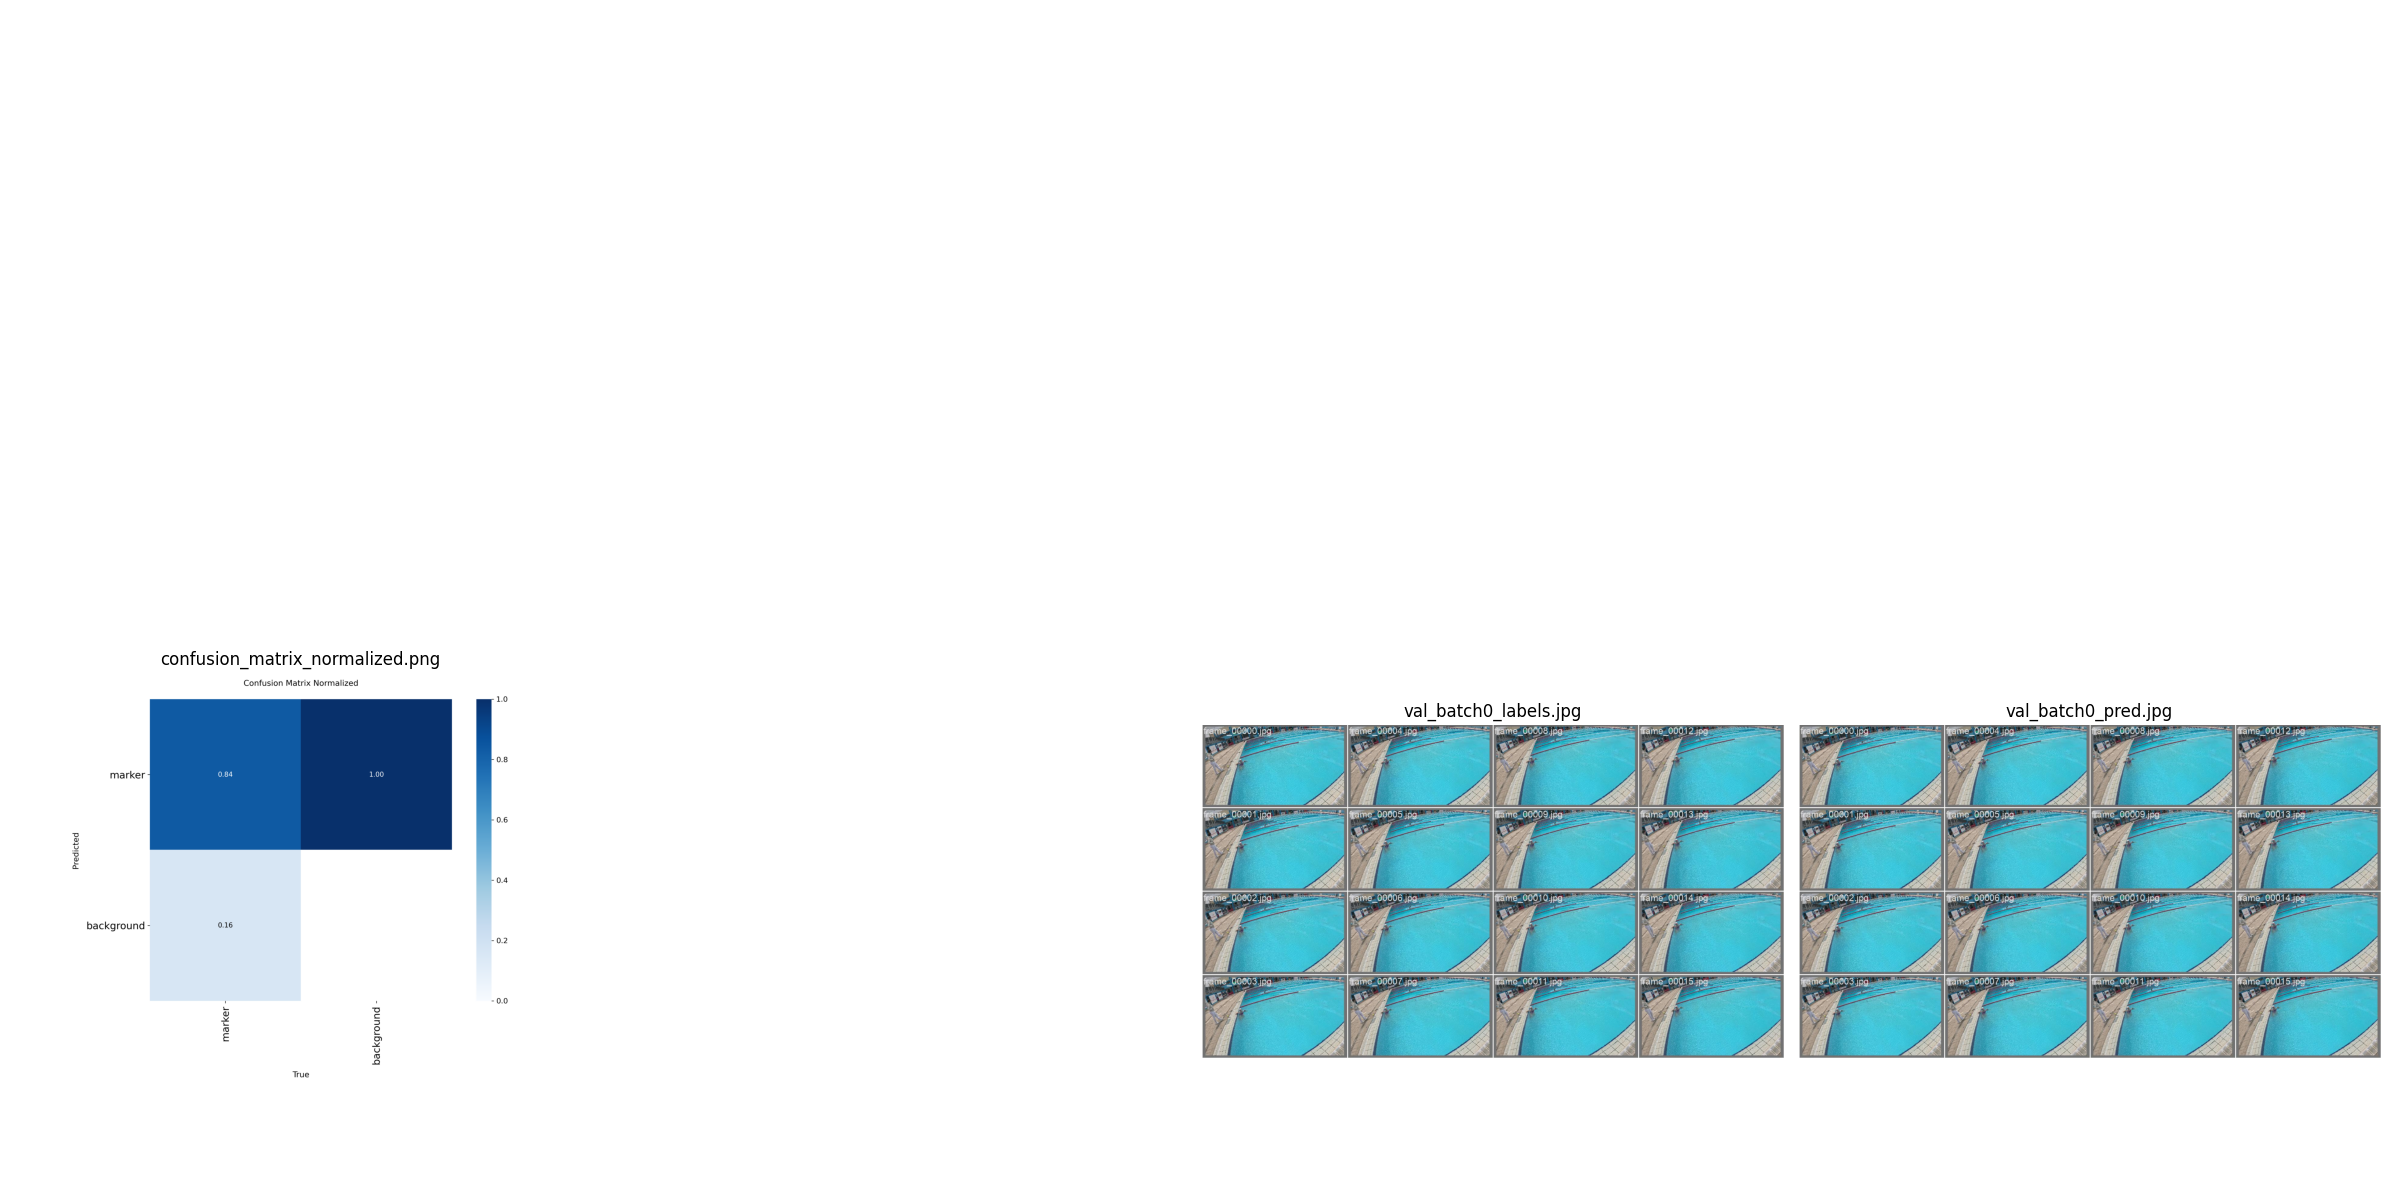


Generating visual evaluation...


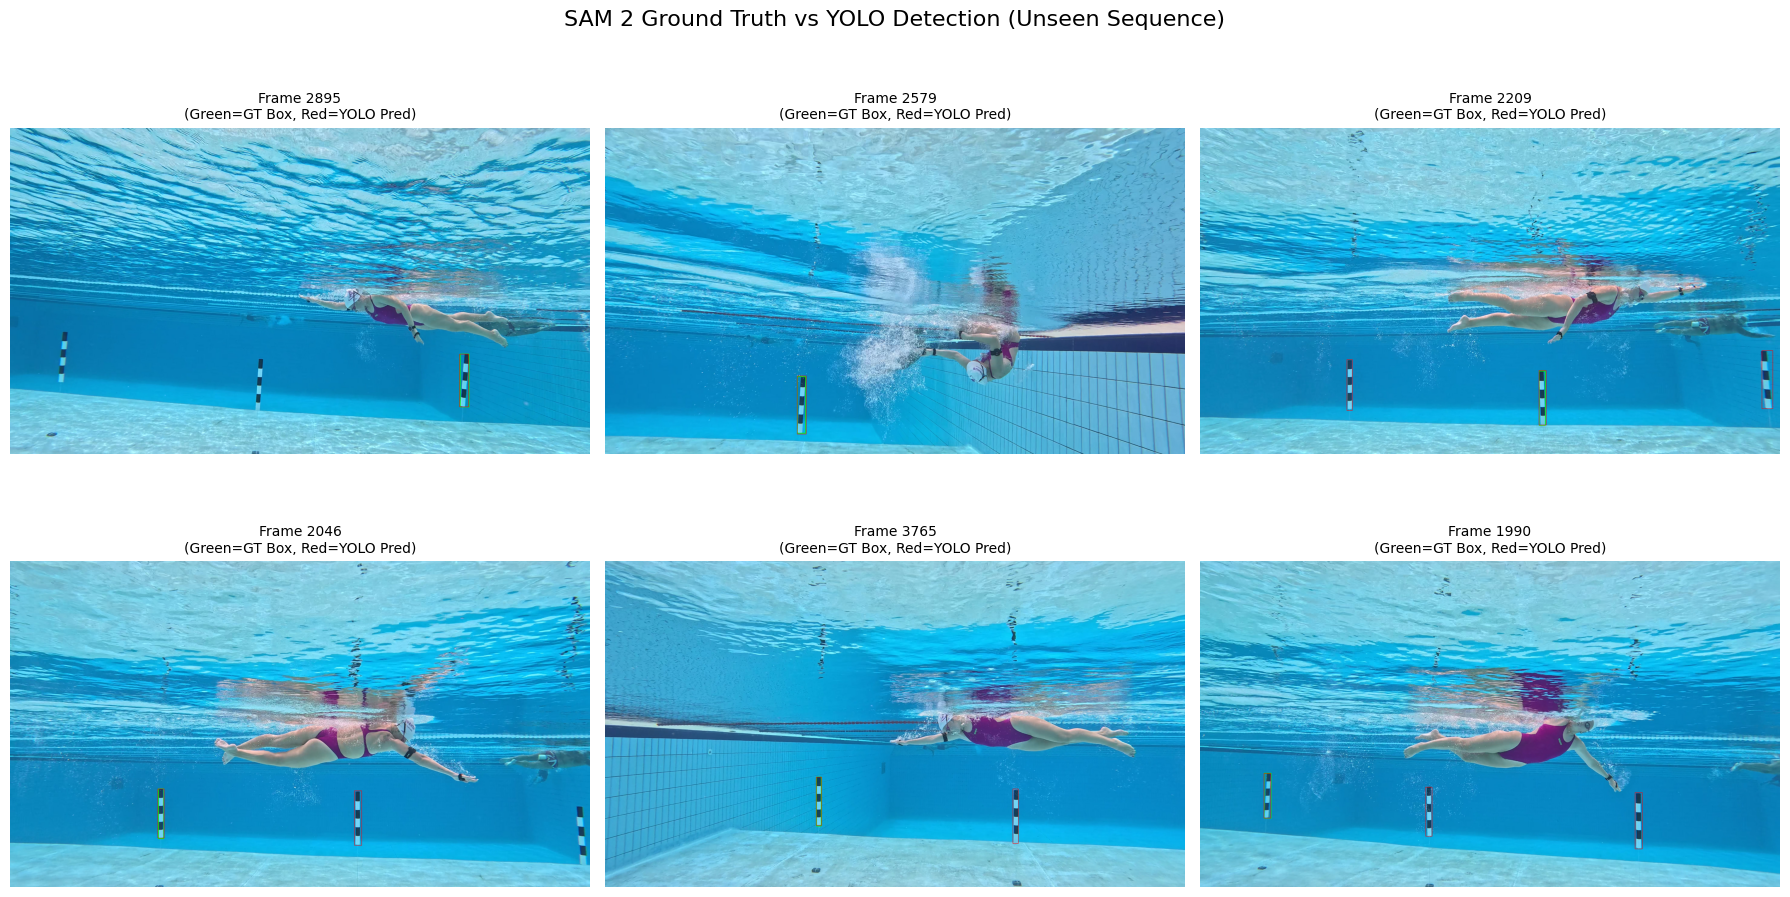

In [3]:
# --- Numerical & Visual Evaluation of YOLO ---
import os
import shutil
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random

# Load Ground Truth
df_gt = pd.read_csv(OUTPUT_CSV)
gt_dict = {}
for _, row in df_gt.iterrows():
    f_id = int(row["Frame_ID"])
    box = [row["X_min"], row["Y_min"], row["X_max"], row["Y_max"]]
    if f_id not in gt_dict:
        gt_dict[f_id] = []
    gt_dict[f_id].append(box)

# Load Fine-tuned Model
model_path = "runs/detect/runs/detect/marker_detector/weights/best.pt"
try:
    eval_model = YOLO(model_path)
    print(f"Loaded evaluation model: {model_path}")
except Exception as e:
    print(f"Could not load model: {e}")
    eval_model = YOLO("yolov8n.pt") # fallback 


# --- ultralytics native mAP computation ---
print("\nPreparing temporary dataset for native YOLO validation...")
VAL_DIR = "temp_yolo_eval"
os.makedirs(os.path.join(VAL_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(VAL_DIR, "labels"), exist_ok=True)

sample_img = cv2.imread(frame_paths[0])
img_h, img_w = sample_img.shape[:2]

# Format bounding boxes into YOLO YOLO (.txt) format
for i, frame_path in enumerate(frame_paths):
    fname = os.path.basename(frame_path)
    base_name = os.path.splitext(fname)[0]
    
    # Symlink/copy image
    dst_img = os.path.join(VAL_DIR, "images", fname)
    if not os.path.exists(dst_img):
        shutil.copy2(frame_path, dst_img)
        
    # Write normalized labels
    label_path = os.path.join(VAL_DIR, "labels", f"{base_name}.txt")
    gt_boxes = gt_dict.get(i, [])
    with open(label_path, "w") as f:
        for box in gt_boxes:
            x_min, y_min, x_max, y_max = box
            cx = (x_min + x_max) / 2.0 / img_w
            cy = (y_min + y_max) / 2.0 / img_h
            bw = (x_max - x_min) / img_w
            bh = (y_max - y_min) / img_h
            f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

# Write config yaml
yaml_path = os.path.join(VAL_DIR, "eval.yaml")
with open(yaml_path, "w") as f:
    f.write(f"path: {os.path.abspath(VAL_DIR)}\n")
    f.write("train: images\n")
    f.write("val: images\n")
    f.write("nc: 1\n")
    f.write("names: ['marker']\n")

print("Running YOLO validation metrics calculation...")
metrics = eval_model.val(data=yaml_path, split='val', plots=True, verbose=False)

print(f"\n--- YOLO Validation Metrics ({len(frame_paths)} frames) ---")
print(f"metrics/precision(B): {metrics.box.mp:.4f}")
print(f"metrics/recall(B):    {metrics.box.mr:.4f}")
print(f"metrics/mAP50(B):     {metrics.box.map50:.4f}")
print(f"metrics/mAP50-95(B):  {metrics.box.map:.4f}")

# Display plotted metrics
model_dir = eval_model.ckpt_path.split("/weights")[0] if getattr(eval_model, 'ckpt_path', None) else eval_model.task

print("\n--- Model Performance Curves ---")
results_img_path = os.path.join(metrics.save_dir, "results.png")
if os.path.exists(results_img_path):
    img = cv2.imread(results_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Results")
    plt.show()

# If results.png is not found or plots=True generated curve files
curve_files = ["F1_curve.png", "P_curve.png", "PR_curve.png", "R_curve.png", "confusion_matrix_normalized.png", "labels_correlogram.jpg", "val_batch0_labels.jpg", "val_batch0_pred.jpg"]
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

plotted = 0
for i, curve_file in enumerate(curve_files):
    curve_path = os.path.join(metrics.save_dir, curve_file)
    if os.path.exists(curve_path):
        img = cv2.imread(curve_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(curve_file)
        axes[i].axis('off')
        plotted += 1
    else:
        axes[i].axis('off')

if plotted > 0:
    plt.tight_layout()
    plt.show()
else:
    plt.close(fig)
    print("Could not locate performance curves in the metrics save directory.")


# Cleanup temporary eval directory to avoid cluttering workspace
shutil.rmtree(VAL_DIR, ignore_errors=True)

print("\nGenerating visual evaluation...")
%matplotlib inline

gt_frames = list(gt_dict.keys())
if len(gt_frames) > 0:
    # Pick 6 random frames that possess a ground truth marker
    samples = random.sample(gt_frames, min(6, len(gt_frames)))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    for ax, f_idx in zip(axes.flat, samples):
        img_bgr = cv2.imread(frame_paths[f_idx])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Draw Ground Truth (Green, thick)
        if f_idx in gt_dict:
            for gb in gt_dict[f_idx]:
                cv2.rectangle(img_rgb, (int(gb[0]), int(gb[1])), (int(gb[2]), int(gb[3])), (0, 255, 0), 4)
        
        # Predict & Draw Prediction (Red, inner)
        res = eval_model(frame_paths[f_idx], verbose=False)[0]
        pbs = res.boxes.xyxy.cpu().numpy()
        for pb in pbs:
            cv2.rectangle(img_rgb, (int(pb[0]), int(pb[1])), (int(pb[2]), int(pb[3])), (255, 0, 0), 2)
            
        ax.imshow(img_rgb)
        ax.set_title(f"Frame {f_idx}\n(Green=GT Box, Red=YOLO Pred)", fontsize=10)
        ax.axis('off')
        
    plt.suptitle("SAM 2 Ground Truth vs YOLO Detection (Unseen Sequence)", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No tracked frames available to display.")

Comparing results between:
1. runs/detect/runs/detect/marker_detector
2. runs/detect/val6

results.csv not found in one or both directories. Skipping numeric comparison.



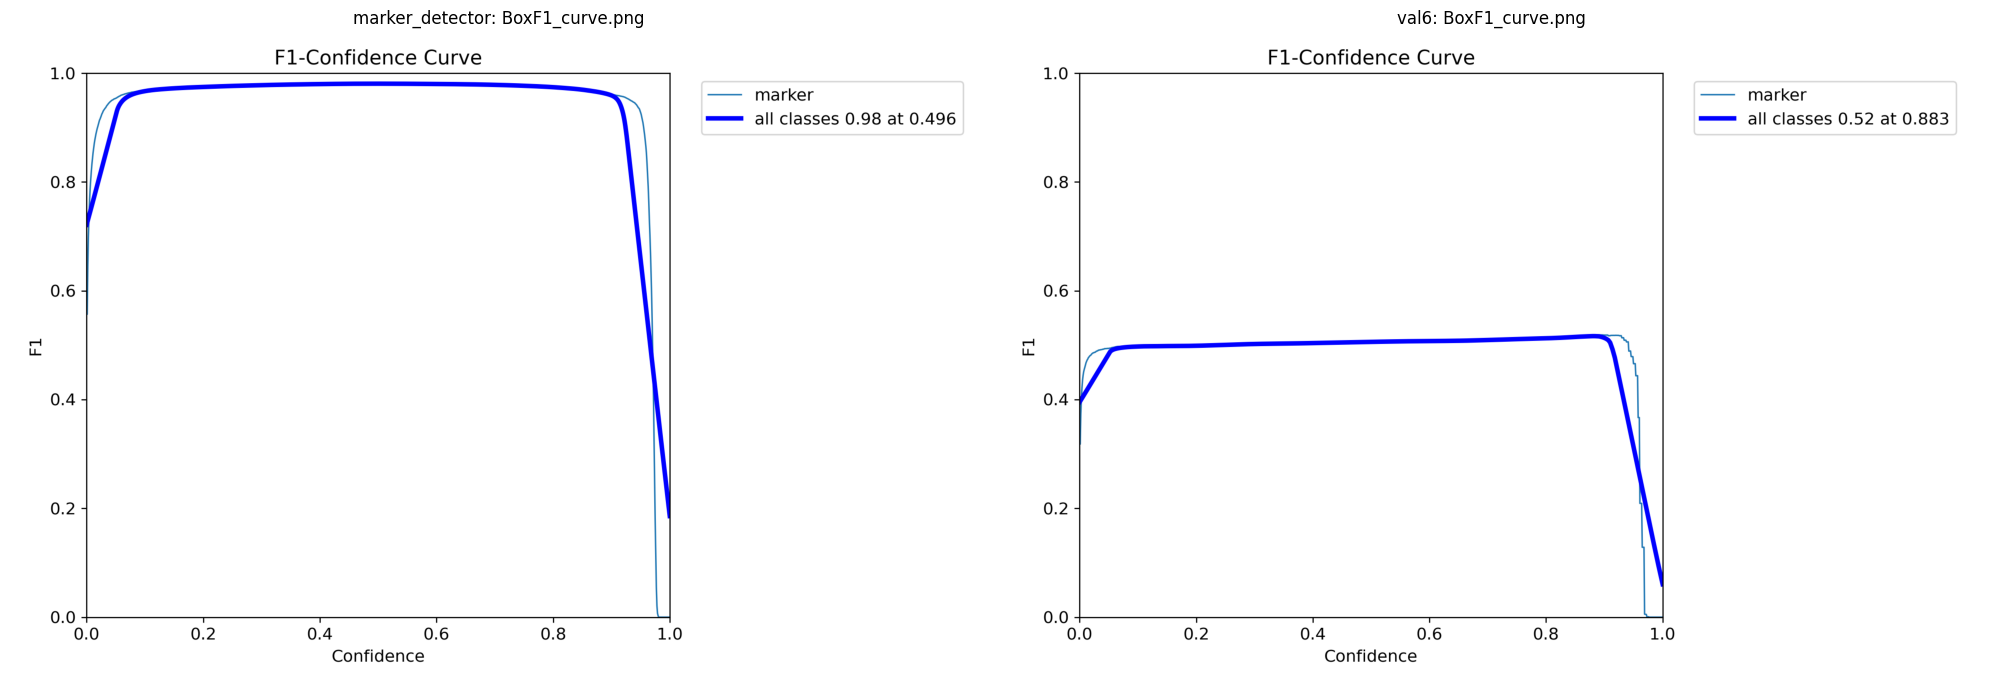

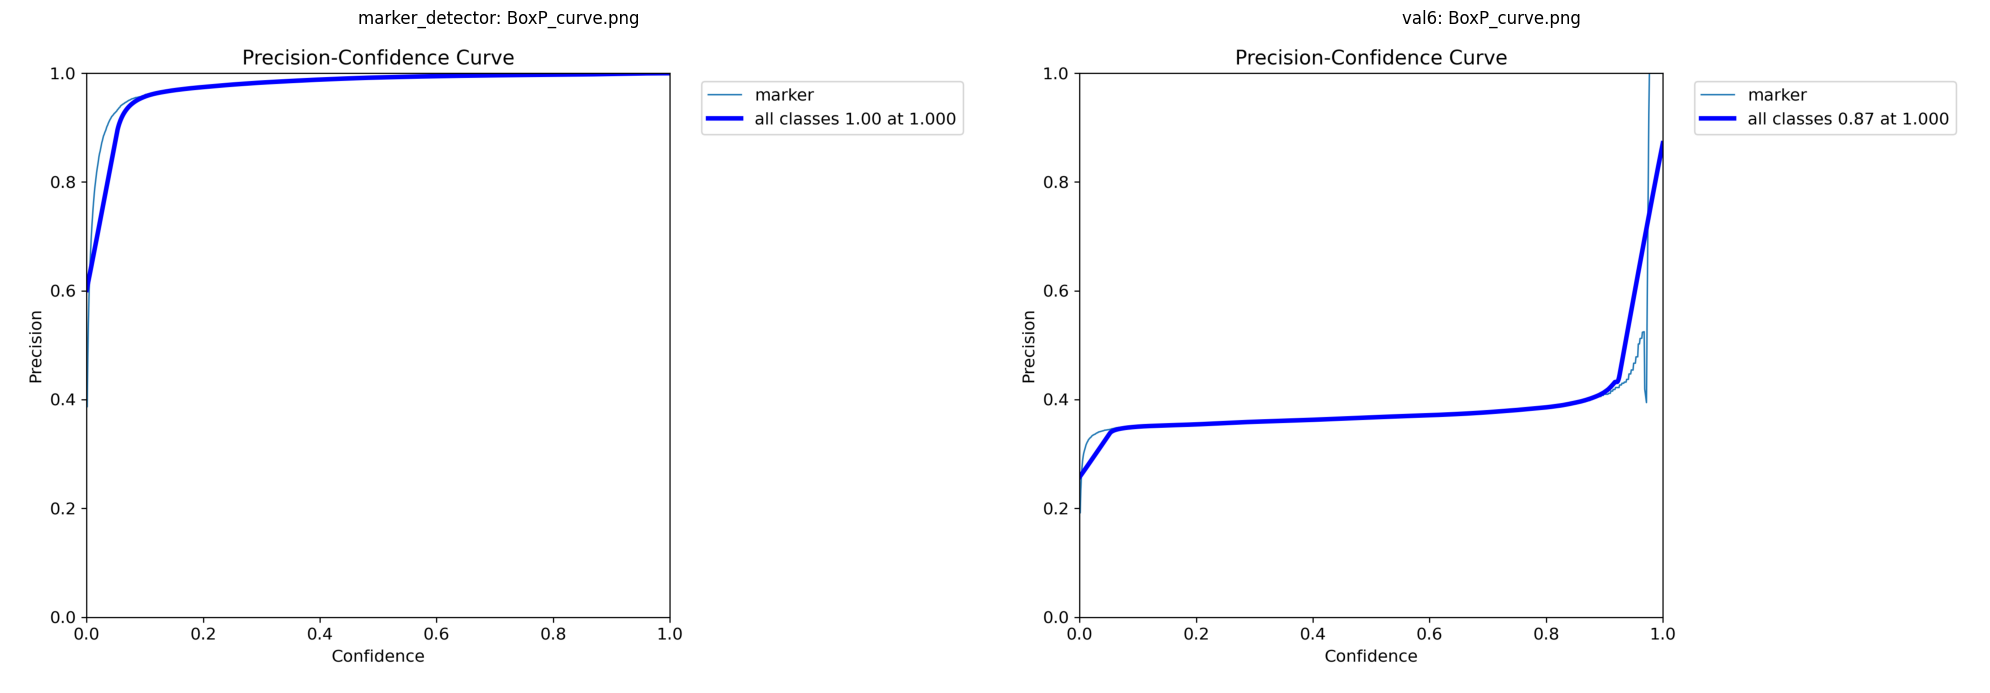

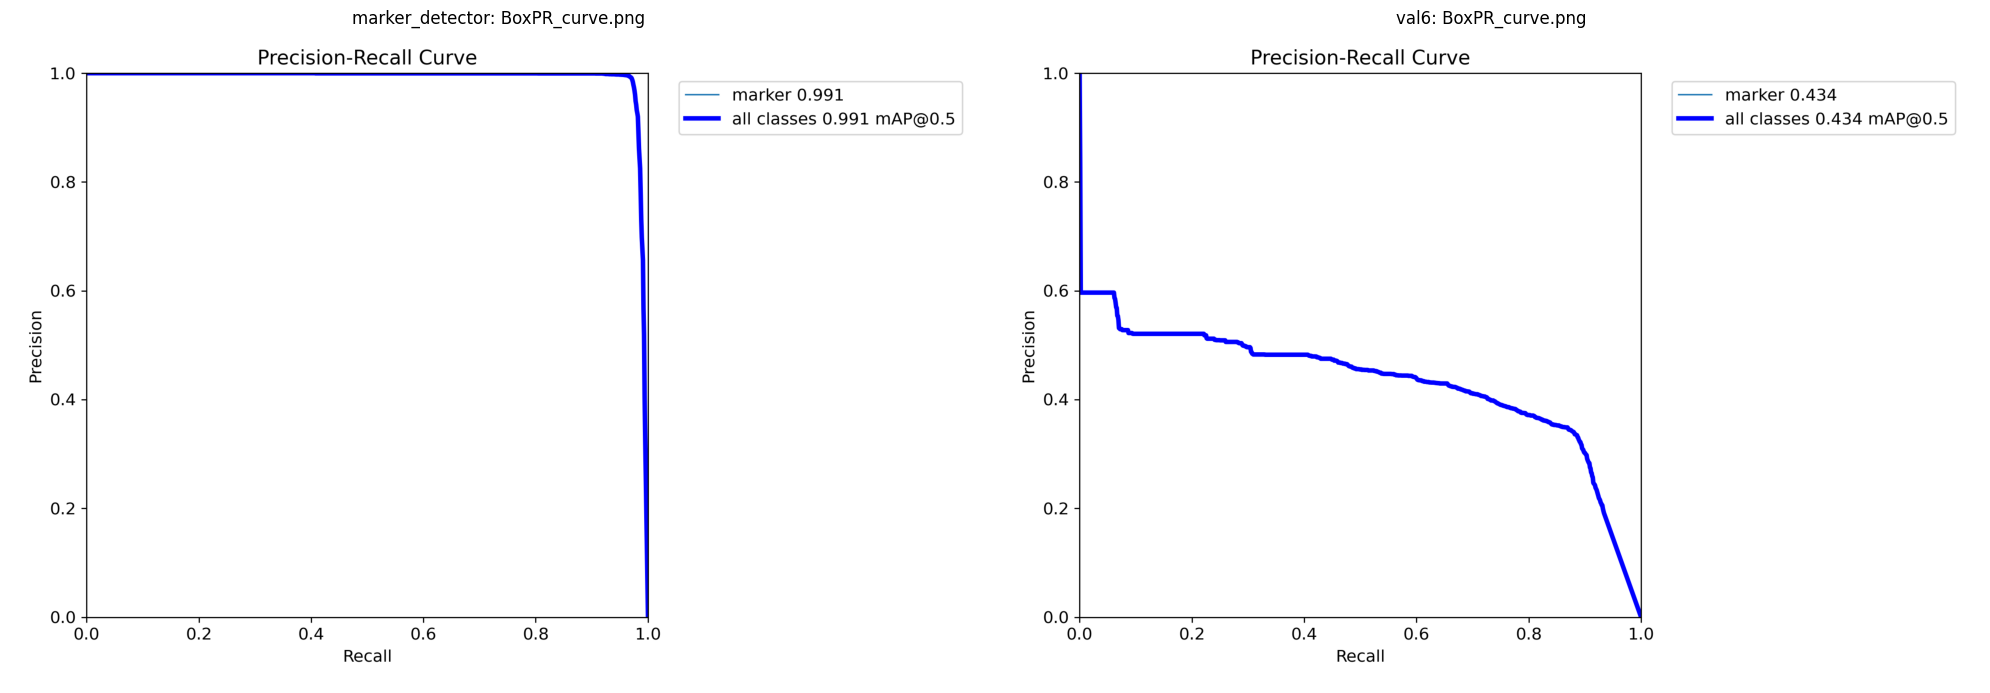

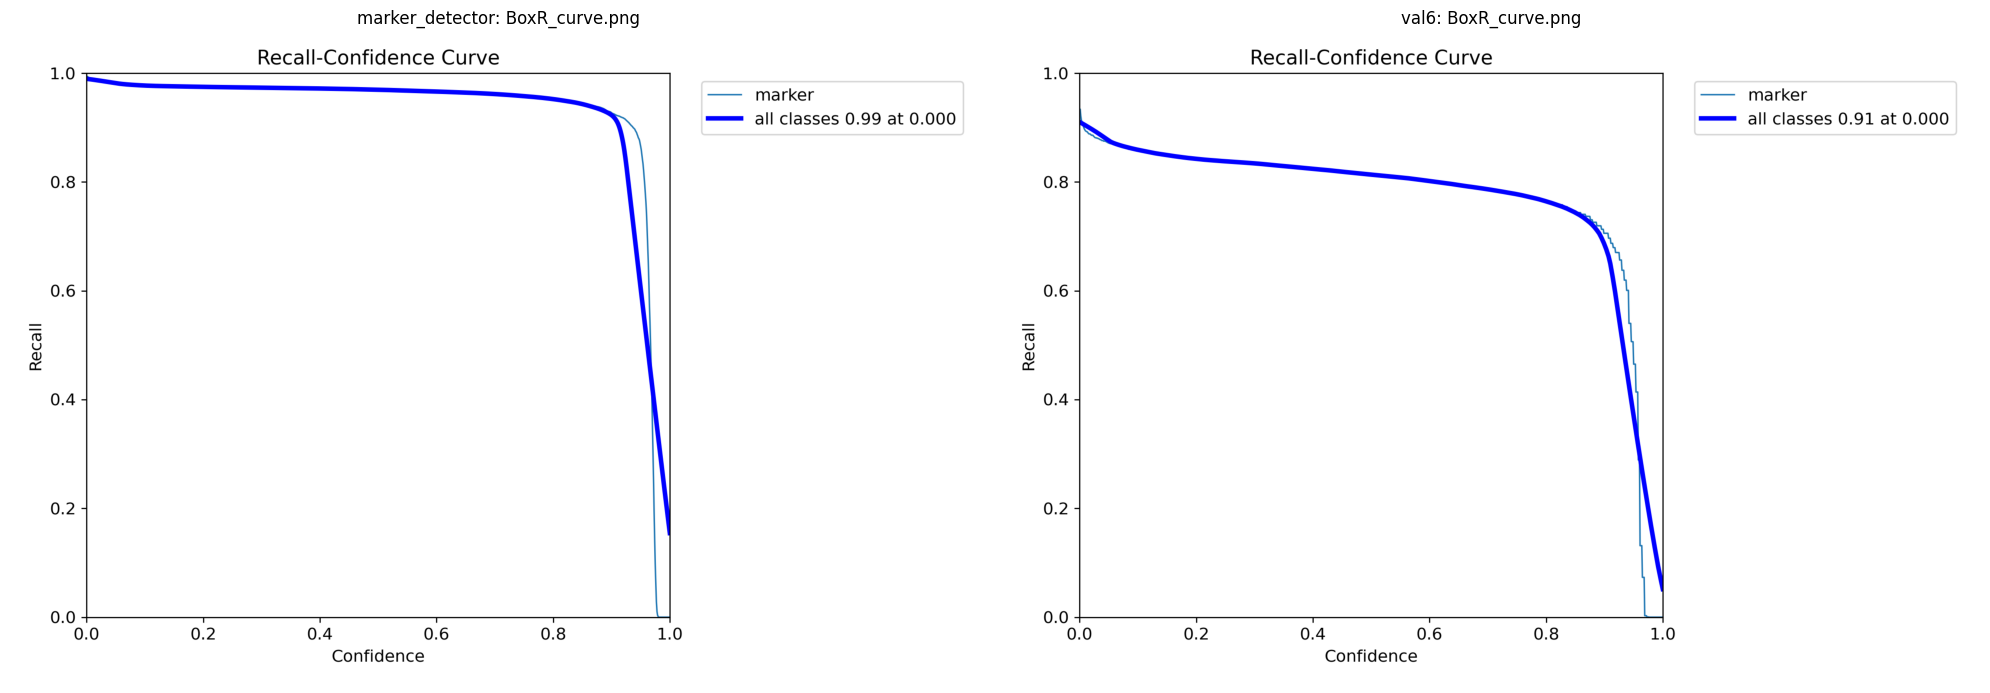

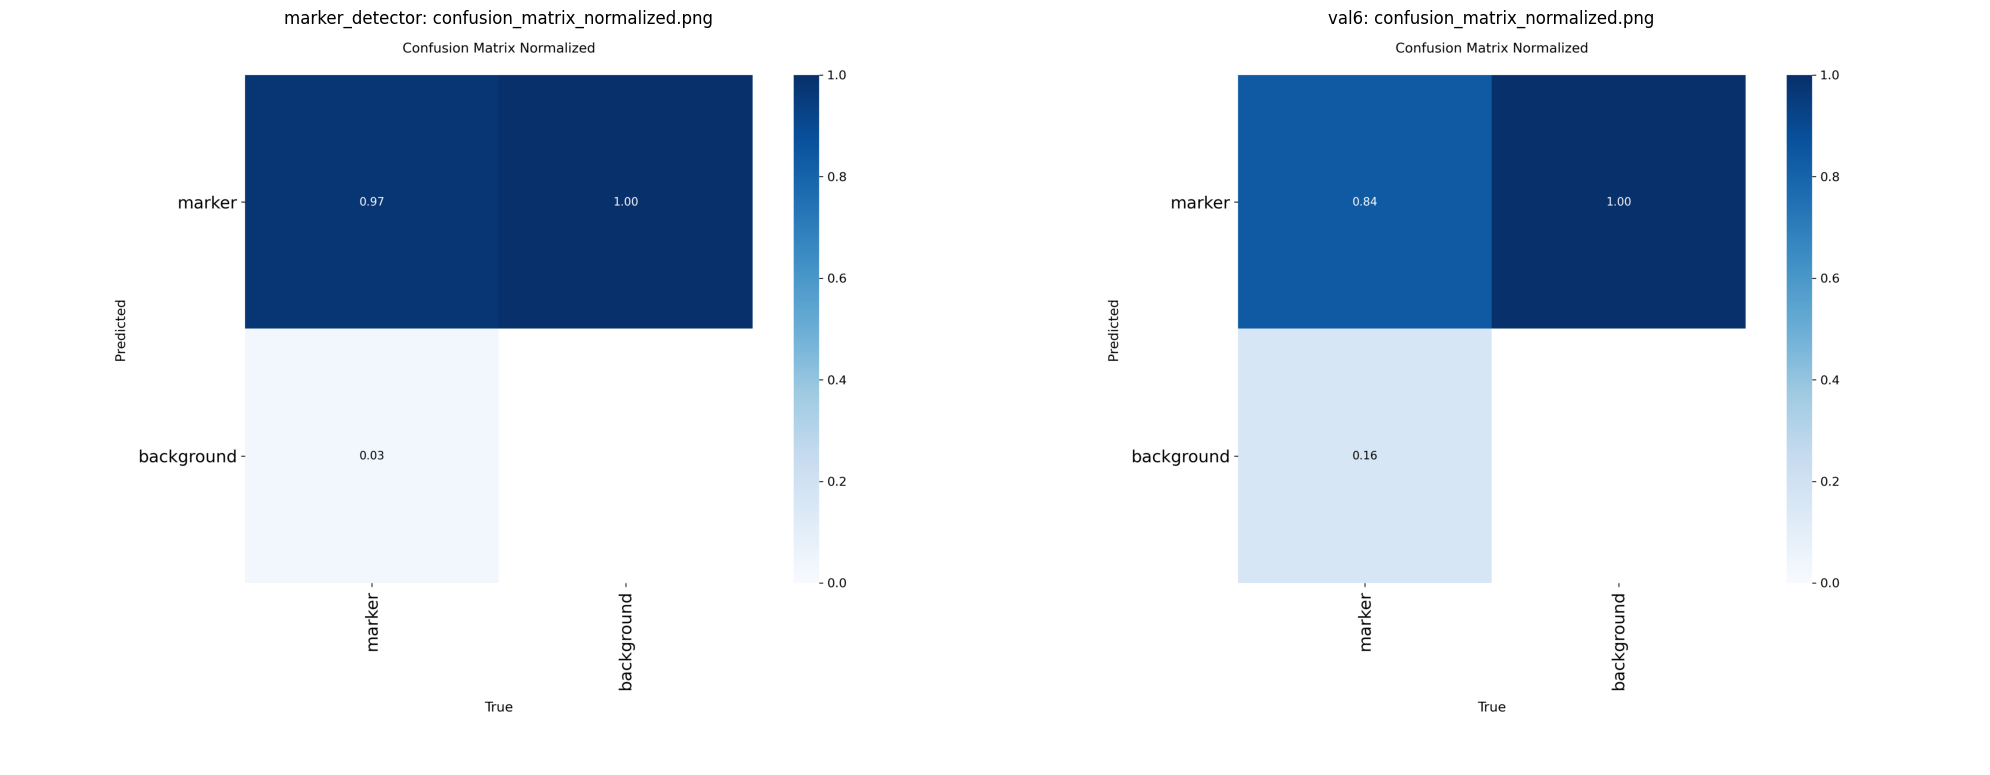

In [2]:
# --- Compare Results: marker_detector vs val6 ---
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd

dir_model = "runs/detect/runs/detect/marker_detector"
dir_val6 = "runs/detect/val6"

print(f"Comparing results between:\n1. {dir_model}\n2. {dir_val6}\n")

# 1. Compare results.csv if available
csv_model = os.path.join(dir_model, "results.csv")
csv_val6 = os.path.join(dir_val6, "results.csv")

if os.path.exists(csv_model) and os.path.exists(csv_val6):
    df_model = pd.read_csv(csv_model)
    df_val6 = pd.read_csv(csv_val6)

    # Strip whitespace from column names if any
    df_model.columns = df_model.columns.str.strip()
    df_val6.columns = df_val6.columns.str.strip()

    # Get last epoch metrics
    last_model = df_model.iloc[-1]
    last_val6 = df_val6.iloc[-1]

    metrics = ['metrics/precision(B)', 'metrics/recall(B)',
               'metrics/mAP50(B)', 'metrics/mAP50-95(B)']

    print("--- Final Epoch Metrics Comparison ---")
    print(f"{'Metric':<25} | {'marker_detector':<20} | {'val6':<20}")
    print("-" * 70)
    for m in metrics:
        v1 = last_model.get(m, 'N/A')
        v2 = last_val6.get(m, 'N/A')
        if isinstance(v1, float):
            v1 = f"{v1:.4f}"
        if isinstance(v2, float):
            v2 = f"{v2:.4f}"
        print(f"{m:<25} | {v1:<20} | {v2:<20}")
    print("\n")
else:
    print("results.csv not found in one or both directories. Skipping numeric comparison.\n")

# 2. Visual Comparison of Curves
curves_to_compare = ["BoxF1_curve.png", "BoxP_curve.png",
                     "BoxPR_curve.png", "BoxR_curve.png", "confusion_matrix_normalized.png"]

for curve in curves_to_compare:
    img_path1 = os.path.join(dir_model, curve)
    img_path2 = os.path.join(dir_val6, curve)

    exists1 = os.path.exists(img_path1)
    exists2 = os.path.exists(img_path2)

    if exists1 or exists2:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        if exists1:
            img1 = cv2.imread(img_path1)
            img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
            axes[0].imshow(img1)
            axes[0].set_title(f"marker_detector: {curve}")
        else:
            axes[0].text(0.5, 0.5, 'Image not found', ha='center', va='center')
            axes[0].set_title(f"marker_detector: {curve} (Missing)")
        axes[0].axis('off')

        if exists2:
            img2 = cv2.imread(img_path2)
            img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
            axes[1].imshow(img2)
            axes[1].set_title(f"val6: {curve}")
        else:
            axes[1].text(0.5, 0.5, 'Image not found', ha='center', va='center')
            axes[1].set_title(f"val6: {curve} (Missing)")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()